# GISLR · Stage 1 — `StreamingGRU` on the top-3 landmark subsets

**Pipeline stage** for GISLR (not a standalone diagnostic): per-subset feature caches → all-else-identical GRU training runs → results & run-folder docs → *(deferred)* TFLite export for Kaggle submission.

Overhauled **2026-07-16** to train the **top three subsets** from the discriminability comparison ([docs/2026-07-16.md](../docs/2026-07-16.md)) as controlled ablations (TODO §3.1). GISLR is a competition dataset — grading/submission is a separate, later step (§8), so nothing here touches the Kaggle test server:

| rank | subset | landmarks | probe acc (global) | status |
|---|---|---|---|---|
| 1 | `ME_126` | 126 | 0.4994 | already trained: run `20260715-190729`, 73.73% val — kept in the default list as a reproducibility re-run; remove it from `TRAIN_SUBSETS` to save ≈25 GPU-min |
| 2 | `ME_132` | 132 | 0.4978 | new run |
| 3 | `FP_118` | 118 | 0.4860 | new run — isolates whether upper-body pose helps a *streaming* model (TODO §3.1) |

**Artifacts produced**

| artifact | path |
|---|---|
| per-subset feature caches (skip-if-exists) | `cache/{train,val}_<tag>_{data,offsets}.npy` |
| run-dir pointer per subset (drives auto-resume) | `cache/gru_runs/<tag>.txt` |
| checkpoints (gitignored) | `models/gislr/gru/<timestamp>/gru_{latest,best}.pt` |
| run docs (the committed record) | `models/gislr/gru/<timestamp>/{README.md,data.md}` |
| landmark indices + hyperparams | `models/gislr/gru/<timestamp>/cache/{landmarks.npy,hyp.json}` |
| learning curves | `models/gislr/gru/<timestamp>/assets/learning_loss_accuracy.png` |
| export artifacts (§8, deferred, gitignored) | `models/gislr/gru/<timestamp>/export/` |

**Resumability** — cache builds skip existing files and write atomically (temp + `os.replace`); each subset's training auto-resumes from `gru_latest.pt` (checkpoint saved every epoch, atomically) via its pointer file and is skipped entirely once all epochs are done. An interrupt never forces a full rerun.

**Design decisions** (vs the pre-overhaul notebook, per the TODO spec)

- Hyperparameters are **frozen to the `20260713-213000` full-543 baseline** (batch 192, lr 3e-4, hidden 256×2, dropout 0.3, wd 1e-4, 60 epochs, OneCycleLR, CE + label-smoothing 0.1, AMP, seed 42): the landmark subset is the *only* variable (TODO §3.1 "all-else-identical").
- Subset index lists come from the canonical registry [`modules/dataset/landmark/subsets.py`](modules/dataset/landmark/subsets.py) — never re-derived.
- The dataset class is defined **in this notebook** (in-RAM flat arrays, `num_workers=0`, ~0.3 min/epoch): the dead `modules.dataset` import is gone (TODO §0.1) and Windows spawn-pickling no longer matters.
- Canonical per-class evaluation stays in [`scripts/eval_gru.py`](../scripts/eval_gru.py) (identical split/metric to every leaderboard run); §7 prints the exact command per run — **run by the user, after training**.
- §8 (ONNX → TF SavedModel → TFLite) is parameterized by run folder and **deferred** until the per-class eval has picked a submission model.

**Kernel requirements**: project `.venv`, CWD = `src/`, CUDA GPU. Expect ≈25 GPU-min per subset and ≈10 GB of new feature caches (`ME_132` + `FP_118`) on top of `ME_126`'s existing ~5.6 GB.

## 1. Setup

All imports + every shared tunable. **`TRAIN_SUBSETS` is the primary knob** — the §4–§7 cells each re-declare their own working list from it, so tweaking one section never requires re-running another. `COORDS = "xy"` is the future z-drop ablation (TODO §3.1) and flows through cache tags, checkpoints and run docs automatically.

In [1]:
# ============================================================
# Setup — imports, tunables, resolved paths
# ============================================================
import json
import os
import time
from concurrent.futures import ThreadPoolExecutor
from datetime import datetime
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm

from modules.dataset.landmark.subsets import get_subset

SEED = 42            # canonical project seed (split + training)
ROWS_PER_FRAME = 543  # holistic rows per frame (GISLR parquet layout)
MAX_SEQ_LEN = 128    # uniform-subsample cap, identical to the baseline
COORDS = "xyz"       # coordinate channels fed to the model ("xy" drops z — TODO §3.1)

#: top-3 subsets by probe_acc_global (docs/2026-07-16.md) — THE knob of this notebook
TRAIN_SUBSETS = ["ME_126", "ME_132", "FP_118"]

# frozen to the 20260713-213000 full-543 baseline: the input subset must be
# the ONLY variable across these runs (TODO §3.1 "all-else-identical")
HYP = dict(batch_size=192, lr=3e-4, hidden_size=256, num_layers=2,
           dropout=0.3, weight_decay=1e-4, epochs=60, grad_clip=5.0)

CACHE_DIR = Path("cache")             # per-subset feature caches (gitignored)
RUN_PTR_DIR = CACHE_DIR / "gru_runs"  # <tag>.txt -> active run dir (auto-resume)
MODELS_ROOT = Path("models/gislr/gru")
CACHE_DIR.mkdir(exist_ok=True)
RUN_PTR_DIR.mkdir(parents=True, exist_ok=True)

assert torch.cuda.is_available(), "training requires the CUDA build of torch (uv sync)"
device = torch.device("cuda")
torch.backends.cudnn.benchmark = True

# download only the GISLR competition data (never `import modules.paths` —
# that resolves every dataset incl. POPSIGN at import time)
DATA_DIR = Path(kagglehub.competition_download("asl-signs"))
sign2idx = json.loads((DATA_DIR / "sign_to_prediction_index_map.json").read_text())
NUM_CLASSES = len(sign2idx)


def subset_tag(name: str, coords: str = COORDS) -> str:
    """Cache/run tag: 'ME_126' -> 'me126' (+'-xy' when z is dropped) — matches
    the naming of the existing ME-126 caches so they are reused, not rebuilt."""
    tag = name.lower().replace("_", "")
    return tag if coords == "xyz" else f"{tag}-{coords}"


print(torch.__version__, torch.cuda.get_device_name(0))
print(f"DATA_DIR    = {DATA_DIR}")
print(f"CACHE_DIR   = {CACHE_DIR.resolve()}")
print(f"MODELS_ROOT = {MODELS_ROOT.resolve()}")
print(f"{NUM_CLASSES} classes · subsets to train: " + ", ".join(
    f"{n} ({len(get_subset(n))} lm, probe {get_subset(n).probe_acc_global:.4f})"
    for n in TRAIN_SUBSETS))

2.13.0+cu130 NVIDIA GeForce RTX 4080 SUPER
DATA_DIR    = C:\Users\user2\.cache\kagglehub\competitions\asl-signs
CACHE_DIR   = C:\Users\user2\sign2speech\src\cache
MODELS_ROOT = C:\Users\user2\sign2speech\src\models\gislr\gru
250 classes · subsets to train: ME_126 (126 lm, probe 0.4994), ME_132 (132 lm, probe 0.4978), FP_118 (118 lm, probe 0.4860)


## 2. Reusable core

Run-once definitions (functions/classes only, no mutable state): **2.1** canonical split + feature-cache builder · **2.2** dataset / collate / model · **2.3** training driver with auto-resume. Together with §1 these are the only cells later sections depend on — every §3+ cell is independently re-runnable and loads its inputs from disk, not from other cells' live memory.

In [2]:
# ============================================================
# 2.1 Reusable core — canonical split + per-subset feature caches
# ============================================================
def get_canonical_split() -> tuple[pd.DataFrame, pd.DataFrame]:
    """Stratified 90/10 split, random_state=42 — identical to every leaderboard
    run and to scripts/eval_gru.py (the canonical evaluation). Deterministic and
    cheap, so consumer cells call it themselves instead of sharing live state."""
    df = pd.read_csv(DATA_DIR / "train.csv")
    missing = set(df["sign"].unique()) - set(sign2idx)
    assert not missing, f"signs missing from the official label map: {missing}"
    df["label"] = df["sign"].map(sign2idx)
    tr, va = train_test_split(df, test_size=0.1, stratify=df["sign"], random_state=SEED)
    return tr.reset_index(drop=True), va.reset_index(drop=True)


def load_video_subset(path, rows: np.ndarray, coords: str = COORDS) -> np.ndarray:
    """One parquet -> (T, len(rows), len(coords)) float32, NaN->0.
    Row selection happens here so caches only ever hold the subset's data."""
    cols = list(coords)
    table = pq.read_table(path, columns=cols)
    data = np.column_stack([table.column(c).to_numpy() for c in cols])
    n = data.shape[0] // ROWS_PER_FRAME
    arr = data.reshape(n, ROWS_PER_FRAME, len(cols))[:, rows, :].astype(np.float32)
    return np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)


def build_subset_cache(df: pd.DataFrame, prefix: str, subset, coords: str = COORDS):
    """Decode every parquet once into one flat float32 array + frame offsets.

    Resumable policy: skipped when both files exist; writes are atomic
    (temp file + os.replace), so an interrupt never leaves a half-written cache.
    """
    tag = subset_tag(subset.name, coords)
    data_path = CACHE_DIR / f"{prefix}_{tag}_data.npy"
    off_path = CACHE_DIR / f"{prefix}_{tag}_offsets.npy"
    if data_path.exists() and off_path.exists():
        print(f"{prefix}/{tag}: cache exists, skipping")
        return data_path, off_path

    t0 = time.time()
    paths = [DATA_DIR / p for p in df["path"]]
    rows = subset.array
    chunks, offsets = [], [0]
    with ThreadPoolExecutor(12) as ex:
        for i, arr in enumerate(ex.map(lambda p: load_video_subset(p, rows, coords), paths)):
            chunks.append(arr.reshape(-1))
            offsets.append(offsets[-1] + arr.shape[0])
            if i % 5000 == 0:
                print(f"  {prefix}/{tag} {i}/{len(paths)} ({time.time()-t0:.0f}s)", flush=True)
    flat = np.concatenate(chunks)
    for target, payload in ((data_path, flat),
                            (off_path, np.asarray(offsets, dtype=np.int64))):
        tmp = target.with_suffix(".tmp.npy")
        np.save(tmp, payload)
        os.replace(tmp, target)
    print(f"{prefix}/{tag}: cached {len(df)} videos, {flat.nbytes/1e9:.2f} GB "
          f"({time.time()-t0:.0f}s)")
    return data_path, off_path

In [3]:
# ============================================================
# 2.2 Reusable core — in-RAM dataset, collate, StreamingGRU
# ============================================================
class SubsetArrayDataset(Dataset):
    """Flat in-RAM cache + offsets; uniform subsample past MAX_SEQ_LEN.

    In-RAM with num_workers=0 is deliberate: it trains GISLR at ~0.3 min/epoch
    and sidesteps Windows spawn-pickling entirely, which is why this class can
    live in the notebook instead of a module.
    """

    def __init__(self, df, data_path, off_path, feature_dim, max_seq_len=MAX_SEQ_LEN):
        self.labels = df["label"].to_numpy()
        self.data = np.load(data_path)   # ~5 GB for an ME-126-sized train split
        self.offsets = np.load(off_path)
        self.feature_dim = feature_dim
        self.max_seq_len = max_seq_len
        assert len(self.labels) == len(self.offsets) - 1, "cache/split mismatch"

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        d = self.feature_dim
        arr = self.data[self.offsets[i] * d : self.offsets[i + 1] * d].reshape(-1, d)
        T = arr.shape[0]
        if T > self.max_seq_len:
            arr = arr[np.linspace(0, T - 1, self.max_seq_len).astype(int)]
            T = self.max_seq_len
        return torch.from_numpy(np.ascontiguousarray(arr)), T, int(self.labels[i])


def collate_fn(batch):
    batch.sort(key=lambda x: x[1], reverse=True)  # enforce_sorted packing
    feats, lengths, labels = zip(*batch)
    lengths = torch.tensor(lengths, dtype=torch.long)
    labels = torch.tensor(labels, dtype=torch.long)
    padded = torch.zeros(len(feats), int(lengths[0]), feats[0].shape[1])
    for i, f in enumerate(feats):
        padded[i, : f.shape[0]] = f
    return padded, lengths, labels


class StreamingGRU(nn.Module):
    """Unidirectional (causal) GRU — the deployment architecture. Identical to
    the 20260713-213000 baseline and to scripts/eval_gru.py."""

    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3):
        super().__init__()
        self.input_norm = nn.LayerNorm(input_size)
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True,
                          dropout=dropout if num_layers > 1 else 0.0,
                          bidirectional=False)
        self.head = nn.Sequential(nn.LayerNorm(hidden_size), nn.Dropout(dropout),
                                  nn.Linear(hidden_size, num_classes))

    def forward(self, x, lengths):
        x = self.input_norm(x)
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True,
                                      enforce_sorted=True)
        packed_out, _ = self.gru(packed)
        out, _ = pad_packed_sequence(packed_out, batch_first=True)
        idx = (lengths - 1).view(-1, 1, 1).expand(-1, 1, out.size(-1)).to(out.device)
        return self.head(out.gather(1, idx).squeeze(1))

In [4]:
# ============================================================
# 2.3 Reusable core — training driver with auto-resume
# ============================================================
def resolve_run_dir(tag: str) -> Path:
    """models/gislr/gru/<timestamp>/ (timestamp = training start time). The
    pointer file makes re-runs land in the SAME folder only while that run is
    still incomplete (auto-resume after an interrupt). A COMPLETED run is
    never reused: every new training gets a fresh timestamped folder, even
    with identical conditions."""
    ptr = RUN_PTR_DIR / f"{tag}.txt"
    if ptr.exists():
        latest = Path(ptr.read_text().strip()) / "gru_latest.pt"
        if latest.exists():
            ck = torch.load(latest, map_location="cpu", weights_only=False)
            if ck["epoch"] + 1 < HYP["epochs"]:
                return latest.parent  # interrupted -> resume in place
    run_dir = MODELS_ROOT / datetime.now().strftime("%Y%m%d-%H%M%S")
    run_dir.mkdir(parents=True, exist_ok=True)
    ptr.write_text(str(run_dir))
    return run_dir


def atomic_torch_save(state: dict, path: Path) -> None:
    tmp = path.with_suffix(".pt.tmp")
    torch.save(state, tmp)
    os.replace(tmp, path)


def run_epoch(model, loader, criterion, optimizer=None, scheduler=None,
              scaler=None, grad_clip=HYP["grad_clip"], desc=""):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    total_loss, correct, total, lrs = 0.0, 0, 0, []
    ctx = torch.enable_grad() if train_mode else torch.no_grad()
    with ctx:
        for feats, lengths, labels in tqdm(loader, desc=desc, leave=False):
            feats = feats.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            if train_mode:
                optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda"):
                logits = model(feats, lengths)
                loss = criterion(logits, labels)
            if train_mode:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                lrs.append(scheduler.get_last_lr()[0])
            total_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(-1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total, lrs


def train_subset(subset_name: str, coords: str = COORDS) -> Path:
    """Train one all-else-identical GRU run for `subset_name`. Builds missing
    caches and resumes an interrupted run from its gru_latest.pt; a completed
    run is never reused — calling this again trains a NEW timestamped run."""
    subset = get_subset(subset_name)
    tag = subset_tag(subset_name, coords)
    feature_dim = len(subset) * len(coords)

    train_split, val_split = get_canonical_split()
    tr_data, tr_off = build_subset_cache(train_split, "train", subset, coords)
    va_data, va_off = build_subset_cache(val_split, "val", subset, coords)

    torch.manual_seed(SEED)
    np.random.seed(SEED)

    train_ds = SubsetArrayDataset(train_split, tr_data, tr_off, feature_dim)
    val_ds = SubsetArrayDataset(val_split, va_data, va_off, feature_dim)
    g = torch.Generator(); g.manual_seed(SEED)
    train_loader = DataLoader(train_ds, batch_size=HYP["batch_size"], shuffle=True,
                              collate_fn=collate_fn, num_workers=0, generator=g)
    val_loader = DataLoader(val_ds, batch_size=HYP["batch_size"], shuffle=False,
                            collate_fn=collate_fn, num_workers=0)

    model = StreamingGRU(feature_dim, HYP["hidden_size"], HYP["num_layers"],
                         NUM_CLASSES, HYP["dropout"]).to(device)
    n_params = sum(p.numel() for p in model.parameters())

    optimizer = torch.optim.AdamW(model.parameters(), lr=HYP["lr"],
                                  weight_decay=HYP["weight_decay"])
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=HYP["lr"], epochs=HYP["epochs"],
        steps_per_epoch=len(train_loader))
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scaler = torch.amp.GradScaler("cuda")

    run_dir = resolve_run_dir(tag)
    (run_dir / "cache").mkdir(exist_ok=True)
    (run_dir / "assets").mkdir(exist_ok=True)
    np.save(run_dir / "cache" / "landmarks.npy", subset.array)
    (run_dir / "cache" / "hyp.json").write_text(json.dumps(
        {**HYP, "seed": SEED, "max_seq_len": MAX_SEQ_LEN, "coords": coords,
         "subset": subset_name, "n_landmarks": len(subset),
         "feature_dim": feature_dim, "n_params": n_params, "num_workers": 0,
         "training_source": "gislr.1.model.gru.ipynb"}, indent=2))
    print(f"{tag}: run dir {run_dir} · input dim {feature_dim} · params {n_params:,}")

    latest, best = run_dir / "gru_latest.pt", run_dir / "gru_best.pt"
    start_epoch, best_val_acc = 0, 0.0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
    if latest.exists():
        ck = torch.load(latest, map_location=device, weights_only=False)
        model.load_state_dict(ck["model_state"])
        optimizer.load_state_dict(ck["optimizer_state"])
        scheduler.load_state_dict(ck["scheduler_state"])
        start_epoch, best_val_acc, history = ck["epoch"] + 1, ck["best_val_acc"], ck["history"]
        print(f"{tag}: resumed at epoch {start_epoch}, best {best_val_acc:.4f}")
    if start_epoch >= HYP["epochs"]:
        print(f"{tag}: already complete ({start_epoch} epochs, "
              f"best {best_val_acc:.4f}) — skipping")
        return run_dir

    t0 = time.time()
    for epoch in range(start_epoch, HYP["epochs"]):
        tr_loss, tr_acc, lrs = run_epoch(model, train_loader, criterion, optimizer,
                                         scheduler, scaler,
                                         desc=f"{tag} ep{epoch+1} train")
        val_loss, val_acc, _ = run_epoch(model, val_loader, criterion,
                                         desc=f"{tag} ep{epoch+1} val")
        history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)
        history["lr"].extend(lrs)
        is_best = val_acc > best_val_acc
        best_val_acc = max(best_val_acc, val_acc)
        state = {"epoch": epoch, "model_state": model.state_dict(),
                 "optimizer_state": optimizer.state_dict(),
                 "scheduler_state": scheduler.state_dict(),
                 "best_val_acc": best_val_acc, "history": history,
                 "sign2idx": sign2idx,
                 "hyp": {**HYP, "seed": SEED, "max_seq_len": MAX_SEQ_LEN,
                         "num_workers": 0},
                 "feature_dim": feature_dim, "landmarks": subset.array.tolist(),
                 "subset_name": subset_name, "coords": coords}
        atomic_torch_save(state, latest)   # every epoch -> resume-safe
        if is_best:
            atomic_torch_save(state, best)
        print(f"{tag} epoch {epoch+1:03d}/{HYP['epochs']} | tr_loss {tr_loss:.4f} "
              f"acc {tr_acc:.4f} | val_loss {val_loss:.4f} acc {val_acc:.4f}"
              f"{' *BEST*' if is_best else ''} | {(time.time()-t0)/60:.1f} min",
              flush=True)
    print(f"{tag}: DONE best_val_acc={best_val_acc:.4f} run_dir={run_dir}")
    return run_dir

## 3. Canonical split check

Sanity-check the stratified 90/10 seed-42 split that every leaderboard run and `scripts/eval_gru.py` share (85,029 train / 9,448 val). Purely diagnostic — the training driver calls `get_canonical_split()` itself.

In [5]:
# ============================================================
# Canonical split sanity check — must match the leaderboard split exactly
# ============================================================
train_split, val_split = get_canonical_split()
assert len(val_split) == 9448, "val-set size drifted — leaderboard comparability broken"
print(f"train {len(train_split)} / val {len(val_split)} · "
      f"{train_split['sign'].nunique()} classes · "
      f"val classes {val_split['sign'].nunique()}")
display(train_split.head(3))

train 85029 / val 9448 · 250 classes · val classes 250


,path,participant_id,sequence_id,sign,label
0,train_landmark_files/53618/4154717427.parquet,53618,4154717427,sad,189
1,train_landmark_files/37055/8607903.parquet,37055,8607903,duck,67
2,train_landmark_files/27610/3996084463.parquet,27610,3996084463,mad,138


## 4. Feature caches (per subset)

One flat float32 array + offsets index per (split, subset), decoded from raw parquet once and reused by every later run (skip-if-exists, atomic writes). `ME_126`'s cache from the `20260715-190729` run is picked up unchanged thanks to the shared `me126` tag. Delete a file pair in `cache/` to force a rebuild.

In [6]:
# ============================================================
# Build per-subset feature caches (tunable: CACHE_SUBSETS)
# Safe to re-run any time — existing caches are skipped.
# ============================================================
CACHE_SUBSETS = TRAIN_SUBSETS

train_split, val_split = get_canonical_split()
for name in CACHE_SUBSETS:
    subset = get_subset(name)
    build_subset_cache(train_split, "train", subset)
    build_subset_cache(val_split, "val", subset)

total_gb = sum(f.stat().st_size for f in CACHE_DIR.glob("*_data.npy")) / 1e9
print(f"\ntotal feature-cache size on disk: {total_gb:.1f} GB")

train/me126: cache exists, skipping
val/me126: cache exists, skipping
  train/me132 0/85029 (1s)
  train/me132 5000/85029 (4s)
  train/me132 10000/85029 (7s)
  train/me132 15000/85029 (10s)
  train/me132 20000/85029 (14s)
  train/me132 25000/85029 (17s)
  train/me132 30000/85029 (20s)
  train/me132 35000/85029 (23s)
  train/me132 40000/85029 (26s)
  train/me132 45000/85029 (29s)
  train/me132 50000/85029 (32s)
  train/me132 55000/85029 (36s)
  train/me132 60000/85029 (39s)
  train/me132 65000/85029 (42s)
  train/me132 70000/85029 (45s)
  train/me132 75000/85029 (49s)
  train/me132 80000/85029 (52s)
  train/me132 85000/85029 (55s)
train/me132: cached 85029 videos, 5.11 GB (59s)
  val/me132 0/9448 (0s)
  val/me132 5000/9448 (3s)
val/me132: cached 9448 videos, 0.57 GB (7s)
  train/fp118 0/85029 (2s)
  train/fp118 5000/85029 (4s)
  train/fp118 10000/85029 (6s)
  train/fp118 15000/85029 (8s)
  train/fp118 20000/85029 (10s)
  train/fp118 25000/85029 (12s)
  train/fp118 30000/85029 (14s)
  tr

## 5. Training runs (TODO §3.1)

One run folder per subset under `models/gislr/gru/<timestamp>/`, all-else-identical to the full-543 baseline. **Auto-resume**: interrupting and re-running this cell continues each unfinished subset from its last epoch; completed subsets are skipped, so adding a name to `RUN_SUBSETS` later only trains the new one. Per-class evaluation is *not* done here — that is §7's handoff to `scripts/eval_gru.py`.

In [7]:
# ============================================================
# Train one all-else-identical GRU per subset (tunable: RUN_SUBSETS)
# Resume-safe: re-run after any interrupt resumes the unfinished run.
# NOTE: finished runs are NOT skipped — re-running this cell trains a
# fresh run (new timestamped folder) per subset, even with identical
# conditions. Trim RUN_SUBSETS if you don't want that.
# ============================================================
RUN_SUBSETS = TRAIN_SUBSETS

run_dirs = {}
for name in RUN_SUBSETS:
    run_dirs[name] = train_subset(name)

print("\nrun folders:")
for name, rd in run_dirs.items():
    print(f"  {name}: {rd}")

train/me126: cache exists, skipping
val/me126: cache exists, skipping
me126: run dir models\gislr\gru\20260716-213901 · input dim 378 · params 948,718


me126 ep1 train:   0%|          | 0/443 [00:00<?, ?it/s]

me126 ep1 val:   0%|          | 0/50 [00:00<?, ?it/s]

me126 epoch 001/60 | tr_loss 5.6542 acc 0.0043 | val_loss 5.5262 acc 0.0075 *BEST* | 0.3 min


me126 ep2 train:   0%|          | 0/443 [00:00<?, ?it/s]

...

fp118 ep59 val:   0%|          | 0/50 [00:00<?, ?it/s]

fp118 epoch 059/60 | tr_loss 1.6217 acc 0.8306 | val_loss 1.8609 acc 0.7454 | 15.9 min


fp118 ep60 train:   0%|          | 0/443 [00:00<?, ?it/s]

fp118 ep60 val:   0%|          | 0/50 [00:00<?, ?it/s]

fp118 epoch 060/60 | tr_loss 1.6210 acc 0.8322 | val_loss 1.8608 acc 0.7456 | 16.2 min
fp118: DONE best_val_acc=0.7460 run_dir=models\gislr\gru\20260716-221157

run folders:
  ME_126: models\gislr\gru\20260716-213901
  ME_132: models\gislr\gru\20260716-215522
  FP_118: models\gislr\gru\20260716-221157


## 6. Learning curves & comparison

Reads each subset's checkpoint **from disk** (via the run pointers), so it works in a fresh kernel without re-running §5. Saves each run's curves into its `assets/` folder and tabulates best val accuracy against the two committed references.

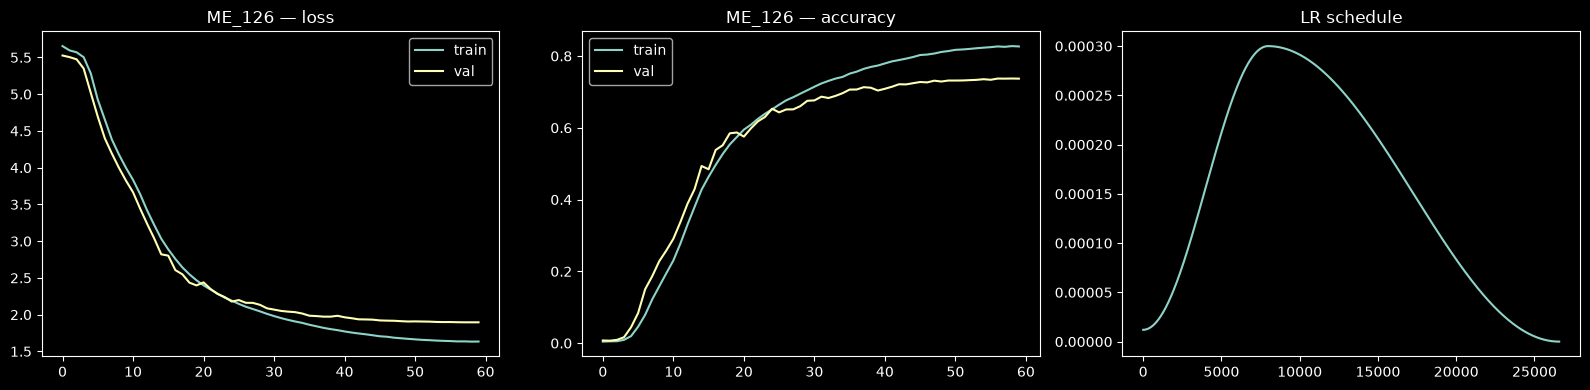

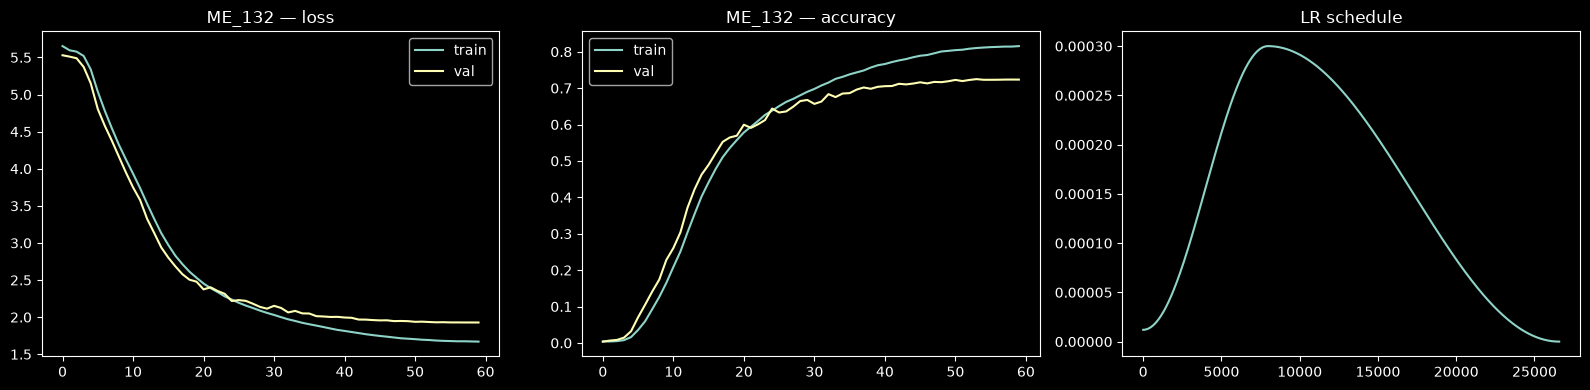

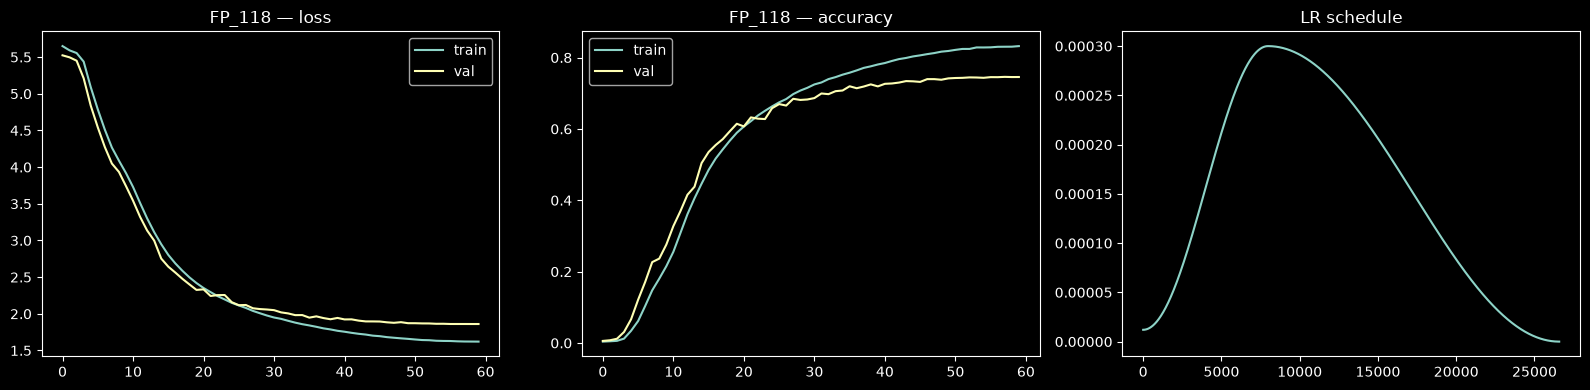

,subset,run,n_landmarks,feature_dim,epochs,best_val_acc,probe_acc
0,FP_118,20260716-221157,118,354,60,0.7460,0.4860
1,ME_126,20260716-213901,126,378,60,0.7373,0.4994
2,ME_132,20260716-215522,132,396,60,0.7247,0.4978


reference — FULL_543 (run 20260713-213000): 0.7059
reference — ME_126 (run 20260715-190729): 0.7373


In [8]:
# ============================================================
# Learning curves + comparison table (tunable: REPORT_SUBSETS)
# Loads gru_latest.pt per run pointer — no dependency on §5 live state.
# ============================================================
REPORT_SUBSETS = TRAIN_SUBSETS
BASELINES = {"FULL_543 (run 20260713-213000)": 0.7059,
             "ME_126 (run 20260715-190729)": 0.7373}

rows = []
for name in REPORT_SUBSETS:
    ptr = RUN_PTR_DIR / f"{subset_tag(name)}.txt"
    if not ptr.exists():
        print(f"{name}: no run pointer yet — train it in §5 first")
        continue
    run_dir = Path(ptr.read_text().strip())
    ck = torch.load(run_dir / "gru_latest.pt", map_location="cpu", weights_only=False)
    h = ck["history"]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(h["train_loss"], label="train")
    axes[0].plot(h["val_loss"], label="val")
    axes[0].set_title(f"{name} — loss"); axes[0].legend()
    axes[1].plot(h["train_acc"], label="train")
    axes[1].plot(h["val_acc"], label="val")
    axes[1].set_title(f"{name} — accuracy"); axes[1].legend()
    axes[2].plot(h["lr"]); axes[2].set_title("LR schedule")
    fig.tight_layout()
    fig.savefig(run_dir / "assets" / "learning_loss_accuracy.png", dpi=110)
    plt.show()

    rows.append(dict(subset=name, run=run_dir.name,
                     n_landmarks=len(get_subset(name)),
                     feature_dim=ck["feature_dim"],
                     epochs=len(h["val_acc"]),
                     best_val_acc=round(ck["best_val_acc"], 4),
                     probe_acc=get_subset(name).probe_acc_global))

if rows:
    display(pd.DataFrame(rows).sort_values("best_val_acc", ascending=False)
            .reset_index(drop=True))
for label, acc in BASELINES.items():
    print(f"reference — {label}: {acc:.4f}")

## 7. Run documentation + canonical per-class eval handoff

Auto-generates each run's `data.md` and a `README.md` **draft** (both required by the registry convention), then prints the exact `scripts/eval_gru.py` command per run — **run those from the repo root yourself**; this notebook never evaluates. Drafts are overwritten on re-run; finalize a README (per-class analysis, leaderboard displacement, `src/models/README.md` update, dated `docs/` report) only after its eval has run.

In [9]:
# ============================================================
# Write data.md + README.md draft + metadata.json per run; print eval commands
# (tunable: DOC_SUBSETS). Reads everything from disk.
# ============================================================
DOC_SUBSETS = TRAIN_SUBSETS

eval_cmds = []
for name in DOC_SUBSETS:
    ptr = RUN_PTR_DIR / f"{subset_tag(name)}.txt"
    if not ptr.exists():
        print(f"{name}: no run yet — skipping")
        continue
    run_dir = Path(ptr.read_text().strip())
    ck = torch.load(run_dir / "gru_latest.pt", map_location="cpu", weights_only=False)
    meta = json.loads((run_dir / "cache" / "hyp.json").read_text())
    subset = get_subset(name)
    epochs_done = len(ck["history"]["val_acc"])
    complete = epochs_done >= HYP["epochs"]
    coords = ck.get("coords", "xyz")
    rd = run_dir.as_posix()

    (run_dir / "data.md").write_text(f"""# Data — GISLR · {name} subset

- **dataset**: Kaggle `asl-signs` (GISLR), 94,477 videos, 250 classes
- **landmark subset**: **{name}** ({len(subset)} landmarks) from the canonical
  registry `src/modules/dataset/landmark/subsets.py`; exact indices in
  [`cache/landmarks.npy`](cache/landmarks.npy)
- **channels**: {coords} -> feature_dim {ck["feature_dim"]}
- **preprocessing**: NaN->0, uniform subsample to <= {MAX_SEQ_LEN} frames
  (identical to the 20260713-213000 baseline)
- **split**: stratified 90/10, `random_state={SEED}` -> 85,029 train /
  9,448 val (the canonical leaderboard split)
- **feature caches**: `src/cache/{{train,val}}_{subset_tag(name, coords)}_{{data,offsets}}.npy`
- **subset provenance**: {subset.provenance}
""", encoding="utf-8")

    status_note = "" if complete else " — **TRAINING INCOMPLETE**"
    eval_cmd = (f".venv/Scripts/python.exe scripts/eval_gru.py "
                f"src/{rd}/gru_best.pt src/{rd} "
                f"--landmarks src/{rd}/cache/landmarks.npy")
    (run_dir / "README.md").write_text(f"""# StreamingGRU — {name} subset ({run_dir.name})

> Draft auto-generated by `gislr.1.model.gru.ipynb` (section 7){status_note}.
> Finalize after running the canonical per-class eval below.

## Training conditions

- architecture: StreamingGRU (unidirectional/causal GRU, hidden {HYP["hidden_size"]} x {HYP["num_layers"]} layers,
  LayerNorm in/out, dropout {HYP["dropout"]}) — {meta["n_params"]:,} params
- input: {name} ({len(subset)} landmarks) x {coords} = {ck["feature_dim"]} features/frame
- hyperparameters (identical to the 20260713-213000 full-543 baseline; the
  landmark subset is the only variable): batch {HYP["batch_size"]}, lr {HYP["lr"]}
  (OneCycleLR), weight decay {HYP["weight_decay"]}, {HYP["epochs"]} epochs,
  grad-clip {HYP["grad_clip"]}, CE + label smoothing 0.1, AMP, seed {SEED},
  max_seq_len {MAX_SEQ_LEN}, num_workers 0 (in-RAM cache)
- data: see [data.md](data.md)

## Results (training loop)

- best val accuracy: **{ck["best_val_acc"]:.4f}** ({epochs_done}/{HYP["epochs"]} epochs)
- references: FULL_543 baseline 70.59% (20260713-213000) · ME_126 73.73% (20260715-190729)

![learning curves](assets/learning_loss_accuracy.png)

## Canonical per-class evaluation — PENDING

Run from the repo root:

```bash
{eval_cmd}
```

Then record overall/macro accuracy + per-class artifacts here and update the
leaderboard in `src/models/README.md` (displacement requires this exact
split/metric).
""", encoding="utf-8")

    # metadata.json — the machine-readable run record aggregated into
    # src/models/index.csv by scripts/build_model_index.py. Canonical-eval
    # fields written by scripts/eval_gru.py survive notebook re-runs.
    meta_path = run_dir / "metadata.json"
    prev = json.loads(meta_path.read_text()) if meta_path.exists() else {}
    best_epoch = int(np.argmax(ck["history"]["val_acc"])) + 1 if complete else None
    metadata = {
        "schema_version": 1,
        "run_id": run_dir.name,
        "dataset": "gislr",
        "architecture": "gru",
        "model_name": "StreamingGRU",
        "streaming": True,
        "subset": name,
        "n_landmarks": len(subset),
        "coords": coords,
        "feature_dim": int(ck["feature_dim"]),
        "n_params": meta["n_params"],
        "n_classes": 250,
        "split": f"stratified 90/10, random_state={SEED}",
        "n_val": 9448,
        "trained_date": f"{run_dir.name[:4]}-{run_dir.name[4:6]}-{run_dir.name[6:8]}",
        "training_source": "gislr.1.model.gru.ipynb",
        "epochs": epochs_done,
        "best_epoch": best_epoch,
        "train_val_acc": round(float(ck["best_val_acc"]), 4),
        "eval_status": prev.get("eval_status", "pending"),
        "overall_accuracy": prev.get("overall_accuracy"),
        "macro_accuracy": prev.get("macro_accuracy"),
        "median_class_accuracy": prev.get("median_class_accuracy"),
        "n_classes_below_50pct": prev.get("n_classes_below_50pct"),
        "hyperparameters": {
            "batch_size": HYP["batch_size"], "lr": HYP["lr"],
            "lr_schedule": "OneCycleLR", "loss": "CE + label smoothing 0.1",
            "precision": "AMP", "hidden_size": HYP["hidden_size"],
            "num_layers": HYP["num_layers"], "dropout": HYP["dropout"],
            "weight_decay": HYP["weight_decay"], "grad_clip": HYP["grad_clip"],
            "seed": SEED, "max_seq_len": MAX_SEQ_LEN, "num_workers": 0,
        },
        "notes": prev.get("notes",
                          f"{name} subset ablation (all-else-identical vs 20260713-213000)."),
    }
    meta_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    eval_cmds.append((name, complete, eval_cmd))
    print(f"{name}: wrote {run_dir / 'data.md'}, README.md draft + metadata.json "
          f"({'complete' if complete else f'{epochs_done}/{HYP['epochs']} epochs'})")

print("\n=== canonical per-class eval — run these from the repo root (user) ===")
for name, complete, cmd in eval_cmds:
    print(f"\n# {name}{'' if complete else '  (WAIT: training incomplete)'}\n{cmd}")
print("\nafterwards: rebuild the index (scripts/build_model_index.py), update")
print("src/models/README.md leaderboard + file a dated docs/ report")

ME_126: wrote models\gislr\gru\20260716-213901\data.md and README.md draft (complete)
ME_132: wrote models\gislr\gru\20260716-215522\data.md and README.md draft (complete)
FP_118: wrote models\gislr\gru\20260716-221157\data.md and README.md draft (complete)

=== canonical per-class eval — run these from the repo root (user) ===

# ME_126
.venv/Scripts/python.exe scripts/eval_gru.py src/models/gislr/gru/20260716-213901/gru_best.pt src/models/gislr/gru/20260716-213901 --landmarks src/models/gislr/gru/20260716-213901/cache/landmarks.npy

# ME_132
.venv/Scripts/python.exe scripts/eval_gru.py src/models/gislr/gru/20260716-215522/gru_best.pt src/models/gislr/gru/20260716-215522 --landmarks src/models/gislr/gru/20260716-215522/cache/landmarks.npy

# FP_118
.venv/Scripts/python.exe scripts/eval_gru.py src/models/gislr/gru/20260716-221157/gru_best.pt src/models/gislr/gru/20260716-221157 --landmarks src/models/gislr/gru/20260716-221157/cache/landmarks.npy

afterwards: update src/models/README.md

## 8. TFLite export chain — DEFERRED (Kaggle submission step)

Run **only after** §7's per-class eval has picked the submission model, then set `EXPORT_RUN_DIR` below. ONNX → TF SavedModel → TFLite with the grader's exact `serving_default` convention (`inputs (T, 543, 3)` → `outputs (250,)`).

Notes:
1. NaN→0 and the landmark-subset gather live **inside the exported graph**, so the grader's raw full-543 frames (NaNs included) work unchanged.
2. The wrapper feeds the *full* sequence to the GRU (no ≥128-frame subsample), same as the original baseline export — but training/eval subsample longer sequences, so verify parity on long videos before submitting.
3. The ONNX export uses **`dynamo=False`** (legacy TorchScript exporter): it maps `nn.GRU` to the native ONNX `GRU` op with a genuinely dynamic frame axis, whereas torch ≥2.9's default dynamo exporter can't trace the recurrence as a dynamic loop (risking specialization to the dummy length) and additionally requires `onnxscript`.
4. Dependencies `onnx`, `onnxruntime`, `onnx2tf` are declared in `pyproject.toml` alongside `tensorflow` (2026-07-16) — `uv sync` if imports fail; never ad-hoc `uv pip install`.

In [18]:
# ============================================================
# (Deferred) Export config + subset-aware inference wrapper + ONNX
# Tunable: EXPORT_RUN_DIR — a finished run folder from §5.
# ============================================================
MODEL_DIR = Path("models/gislr/gru")
EXPORT_RUN_DIR = sorted(MODEL_DIR.glob("202607*"))[1]

assert EXPORT_RUN_DIR, (
    "set EXPORT_RUN_DIR to a finished run folder first — "
    "§8 is the deferred Kaggle-submission step"
)
export_run = Path(EXPORT_RUN_DIR)
EXPORT_DIR = export_run / "export"
EXPORT_DIR.mkdir(exist_ok=True)
print(f"exporting run: {export_run}")

ck = torch.load(export_run / "gru_best.pt", map_location="cpu", weights_only=False)
assert ck.get("coords", "xyz") == "xyz", (
    "grader feeds (T, 543, 3) xyz — xy-only checkpoints need a custom wrapper"
)
base = StreamingGRU(
    ck["feature_dim"],
    ck["hyp"]["hidden_size"],
    ck["hyp"]["num_layers"],
    len(ck["sign2idx"]),
    ck["hyp"]["dropout"],
)
base.load_state_dict(ck["model_state"])
base.eval()


class InferenceWrapper(nn.Module):
    """Grader calling convention: raw (T, 543, 3) frames in (NaNs included),
    (NUM_CLASSES,) scores out. NaN cleanup + landmark selection live INSIDE
    the graph so the exported model owns its preprocessing."""

    def __init__(self, base_model, landmark_rows):
        super().__init__()
        self.base = base_model
        self.register_buffer("rows", torch.as_tensor(landmark_rows, dtype=torch.long))

    def forward(self, frames):  # (T, 543, 3)
        x = torch.nan_to_num(frames, nan=0.0, posinf=0.0, neginf=0.0)
        x = x[:, self.rows, :].reshape(1, frames.shape[0], -1)  # (1, T, F)
        x = self.base.input_norm(x)
        out, _ = self.base.gru(x)  # single full-length sequence:
        return self.base.head(out[:, -1]).squeeze(0)  # no packing -> ONNX-friendly


infer_model = InferenceWrapper(base, ck["landmarks"]).eval()

# parity check: wrapper forward must equal the training-style packed forward
with torch.no_grad():
    dummy = torch.randn(48, ROWS_PER_FRAME, 3)
    ref = base(dummy[:, ck["landmarks"], :].reshape(1, 48, -1), torch.tensor([48]))
    got = infer_model(dummy)
    assert torch.allclose(ref.squeeze(0), got, atol=1e-5), "wrapper != base forward"
print("wrapper parity OK — exporting ONNX")

# dynamo=False: keep the legacy TorchScript exporter (deprecated but present).
# It maps nn.GRU to the native ONNX GRU op with a truly dynamic frame axis —
# the dynamo/torch.export path can't trace the data-dependent recurrence as a
# dynamic loop (and would pull in onnxscript). Same path as the baseline export.
torch.onnx.export(
    infer_model,
    torch.randn(30, ROWS_PER_FRAME, 3),
    str(EXPORT_DIR / "gru_model.onnx"),
    input_names=["inputs"],
    output_names=["outputs"],
    dynamic_axes={"inputs": {0: "frames"}},
    opset_version=13,
    dynamo=False,
)
print("ONNX export complete:", EXPORT_DIR / "gru_model.onnx")

exporting run: models\gislr\gru\20260715-190729
wrapper parity OK — exporting ONNX


C:\Users\user2\AppData\Local\Temp\ipykernel_3664\3319584082.py:64: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


ONNX export complete: models\gislr\gru\20260715-190729\export\gru_model.onnx


c:\Users\user2\sign2speech\.venv\Lib\site-packages\torch\onnx\_internal\torchscript_exporter\symbolic_opset9.py:4570: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with GRU can cause an error when running the ONNX model with a different batch size. Make sure to save the model with a batch size of 1, or define the initial states (h0/c0) as inputs of the model. 
  return _generic_rnn(


In [19]:
# ============================================================
# (Deferred) ONNX -> TF SavedModel, wrapped with the grader's
# serving_default signature. Requires onnx2tf + tensorflow (see §8 notes).
# ============================================================
import subprocess

result = subprocess.run(
    ["onnx2tf", "-i", str(EXPORT_DIR / "gru_model.onnx"),
     "-o", str(EXPORT_DIR / "saved_model_dir"), "-osd"],
    capture_output=True, text=True)
print(result.stdout[-2000:])
print(result.stderr[-2000:])

import tensorflow as tf

saved_model = tf.saved_model.load(str(EXPORT_DIR / "saved_model_dir"))


class ServingModule(tf.Module):
    def __init__(self, sm):
        super().__init__()
        self.sm = sm

    @tf.function(input_signature=[
        tf.TensorSpec(shape=[None, 543, 3], dtype=tf.float32, name="inputs")])
    def serving_default(self, inputs):
        out = self.sm.signatures["serving_default"](inputs=inputs)
        return {"outputs": next(iter(out.values()))}


serving = ServingModule(saved_model)
tf.saved_model.save(serving, str(EXPORT_DIR / "final_saved_model"),
                    signatures={"serving_default": serving.serving_default})
print("final SavedModel written:", EXPORT_DIR / "final_saved_model")


I0000 00:00:1784222714.059445   10468 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784222717.436449   10468 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\user2\sign2speech\.venv\Scripts\onnx2tf.exe\__main__.py", line 4, in <module>
  File "C:\Users\user2\sign2speech\.venv\Lib\site-packages\onnx2tf\__init__.py", line 1, in <module>
    from onnx2tf.onnx2tf import convert, main
  File "C:\Users\user2\sign2speech\.venv\Lib\site-packa

OSError: SavedModel file does not exist at: models\gislr\gru\20260715-190729\export\saved_model_dir\{saved_model.pbtxt|saved_model.pb}

In [ ]:
# ============================================================
# (Deferred) TFLite conversion + validation with the grader's exact
# calling convention (NaNs in the input included).
# ============================================================
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_saved_model(str(EXPORT_DIR / "final_saved_model"))
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # helps with the 40MB cap
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,  # GRU dynamic-loop ops may need the fallback
]
tflite_model = converter.convert()
tflite_path = EXPORT_DIR / "model.tflite"
tflite_path.write_bytes(tflite_model)
print(f"model.tflite: {tflite_path.stat().st_size / 1e6:.2f} MB (competition cap: 40 MB)")

interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
sigs = list(interpreter.get_signature_list())
assert "serving_default" in sigs, f"missing serving_default in {sigs}"
runner = interpreter.get_signature_runner("serving_default")

dummy = np.random.randn(38, ROWS_PER_FRAME, 3).astype(np.float32)
dummy[np.random.rand(*dummy.shape) < 0.1] = np.nan  # grader data contains NaN
out = runner(inputs=dummy)["outputs"]
assert out.shape[-1] == NUM_CLASSES, out.shape
print("output shape:", out.shape, "· argmax:", int(np.argmax(out)))
print("TFLite validation OK — grader calling convention reproduced")